# Analyse trail — comparaison multi-courses

Ce notebook compare plusieurs courses entre elles en superposant les métriques scalaires et les profils normalisés.

**Structure :**
1. Paramètres et chargement
2. Tableau de synthèse
3. Évolution temporelle des métriques
4. Profils normalisés superposés (0–100 % distance)
5. Modèle de déclin individuel
6. Analyse circadienne comparative

###
### © Gregory Sainton
### Observatoire de Paris / Twinity
### Licence : CC BY-NC-SA 4.0


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trail_analysis_v2 import (
    # Chargement
    load_and_process_race,
    build_races_table,
    # Comparaison scalaire
    plot_races_comparison,
    # Profils normalisés
    normalize_by_distance_pct,
    plot_normalized_profiles,
    plot_decay_model,
    # Analyses single-race réutilisées
    plot_circadian_profile,
    compute_pace_split,
    plot_pace_vs_slope_deviation
)

plt.rcParams['figure.dpi'] = 120

---
## ⚙️ Paramètres

Seule cellule à modifier. Définir un bloc par course.

> **Convention de nommage** : utiliser des noms courts et stables (`saintelyon_2025`, `ecotrail_2026`…). Ces noms servent d'identifiants dans tous les graphiques.

In [ ]:
# ── Paramètres physiologiques de l'athlète ─────────────────────────────
FC_MAX   = 200
FC_MIN   = 40
POIDS_KG = 52
ATHELETE_NAME = "Laura"
# ── Catalogue des courses ───────────────────────────────────────────────
# Chaque entrée = un dict décrivant une course.
# 'fit_path'   : chemin absolu vers le fichier .fit
# 'label'      : nom court affiché dans les graphiques
# 'ravito_km'  : positions des ravitaillements (km) — peut être [] si inconnu
# 'ravito_nom' : noms des ravitaillements
# Les paramètres fc_max / fc_min / poids_kg sont partagés (même athlète).
# Surcharger par course si besoin (ex. athlètes différents).

RACES_CATALOG = [
    {
        'label':      'SaintéLyon 2025',
        'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/SainteLyon_2025-11-29 23:31:00.fit',
        'ravito_km':  [19.2, 34.0, 45.0, 58.8, 65.4],
        'ravito_nom': ['St Christo', 'Ste Catherine', 'St Genou', 'Soucieu', 'Chaponost'],
    },

    {
         'label':      'Ecotrail80 2026',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/EcoTrail de Paris_2026-03-21 10:55:00.fit',
         'ravito_km':  [25.4, 37.7, 47.7, 53.8, 78.3],
         'ravito_nom': ['Buc', 'Chaville', 'Saint Philippe', 'Marcel Bec', 'Saint Cloud'],
    },
    {
         'label':      'Impérial trail 2025',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Imperial trail de Fontainebleau_2025-09-13 06:01:00.fit',
         'ravito_km':  [11, 23.5, 33.5, 46.7, 61],
         'ravito_nom': ['ravito1', 'ravito2', 'ravito3', 'ravito4', 'ravito5'],
    },
    {
         'label':      'Trail de la Haze 2026',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Trail-de-la-haze_2026_05_03 09:00:00.fit',
         'ravito_km':  [10.4],
         'ravito_nom': ['ravito1'],
    },
]

# LAURA
RACES_CATALOG = [
    {
         'label':      'Course 25 Avril 2026',
         'fit_path':   '/home/gsainton/DATA/Trail/DATA/Laura/Running_2026-04-25T16_29_10_LB.fit',
         'ravito_km':  [],
         'ravito_nom': [],
    },
    {
         'label':      'Trail de la Haze 2026',
         'fit_path':   '/home/gsainton/DATA/Trail/DATA/Laura/TrailRunning_2026-05-03T09_00_02_LB.fit',
         'ravito_km':  [10.4],
         'ravito_nom': ['ravito1'],
    },
]

# CONPARATIVE ANALYSIS

RACES_CATALOG = [
        {
         'label':      'Trail de la Haze Greg',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Trail-de-la-haze_2026_05_03 09:00:00.fit',
         'ravito_km':  [10.4],
         'ravito_nom': ['ravito1'],
    },
    {
         'label':      'Trail de la Haze Laura',
         'fit_path':   '/home/gsainton/DATA/Trail/DATA/Laura/TrailRunning_2026-05-03T09_00_02_LB.fit',
         'ravito_km':  [10.4],
         'ravito_nom': ['ravito1'],
    }

]



---
## 1. Chargement et traitement

In [3]:
races = []

for cfg in RACES_CATALOG:
    print(f"Chargement : {cfg['label']} ...")
    try:
        race = load_and_process_race(
            fit_path   = cfg['fit_path'],
            fc_max     = cfg.get('fc_max',   FC_MAX),
            fc_min     = cfg.get('fc_min',   FC_MIN),
            poids_kg   = cfg.get('poids_kg', POIDS_KG),
            ravito_km  = cfg['ravito_km'],
            ravito_nom = cfg['ravito_nom'],
        )
        # Surcharger le label avec celui du catalogue
        race['meta']['name'] = cfg['label']
        races.append(race)
        kpi = race['kpis']
        print(f"  ✅ {kpi['distance_km']:.1f} km | "
              f"D+ {kpi['dplus_m']:.0f} m | "
              f"{kpi['duration_h']:.2f} h | "
              f"GAP méd. {kpi['gap_med_s_km']/60:.0f}'{kpi['gap_med_s_km']%60:02.0f}\"")
    except Exception as e:
        print(f"  ❌ Erreur : {e}")

print(f"\n{len(races)} course(s) chargée(s) sur {len(RACES_CATALOG)} demandée(s).")

Chargement : Trail de la Haze Greg ...
  ✅ 25.7 km | D+ 679 m | 3.06 h | GAP méd. 6'06"
Chargement : Trail de la Haze Laura ...
  ✅ 25.5 km | D+ 723 m | 2.09 h | GAP méd. 4'20"

2 course(s) chargée(s) sur 2 demandée(s).


---
## 2. Tableau de synthèse

> Une ligne par course. Toutes les métriques sont comparables entre courses grâce au GAP qui neutralise le biais topographique.

In [4]:
df_table = build_races_table(races)

# Formatage lisible
display_cols = [
    'name', 'date', 'distance_km', 'dplus_m', 'duration_h',
    'gap_med_s_km', 'cv_gap_pct', 'split_ratio',
    'fc_frac', 'pct_walk', 'decoupling_max',
]
display_cols = [c for c in display_cols if c in df_table.columns]

rename_map = {
    'name':          'Course',
    'date':          'Date',
    'distance_km':   'Dist (km)',
    'dplus_m':       'D+ (m)',
    'duration_h':    'Durée (h)',
    'gap_med_s_km':  'GAP méd. (s/km)',
    'cv_gap_pct':    'CV GAP (%)',
    'split_ratio':   'Ratio split',
    'fc_frac':       'FC/FCmax',
    'pct_walk':      '% marche',
    'decoupling_max':'Découplage max (%)',
}

print(df_table[display_cols].rename(columns=rename_map).to_string(index=False))

                Course       Date  Dist (km)  D+ (m)  Durée (h)  GAP méd. (s/km)  CV GAP (%)  Ratio split  FC/FCmax  % marche  Découplage max (%)
 Trail de la Haze Greg 2026-05-03      25.68   679.0      3.062            366.0        48.0        1.130     0.807      24.5                11.4
Trail de la Haze Laura 2026-05-03      25.48   723.0      2.086            260.0        39.4        1.095     0.773       2.9                10.9


---
## 3. Évolution temporelle des métriques

> Chaque panneau montre l'évolution d'un indicateur au fil des courses, avec une tendance linéaire si ≥ 3 points. Identifier les progrès, les régressions, et les anomalies.

In [5]:
if len(races) >= 2:
    plot_races_comparison(
        df_table,
        metrics=[
            'gap_med_s_km',
            'cv_gap_pct',
            'split_ratio',
            'fc_frac',
            'pct_walk',
            'decoupling_max',
        ],
    )
else:
    print('Au moins 2 courses nécessaires pour la comparaison temporelle.')

---
## 4. Profils normalisés — GAP sur 0–100 % de la distance

> Les courses sont ramenées sur un axe commun 0–100 % de leur distance respective. Cela permet de superposer des courses de longueurs différentes et de voir où, dans la structure de la course, chaque athlète accélère ou ralentit.

> **Référence** : Kerhervé, Millet & Solomon (2015). *PLoS ONE*.

In [6]:
if len(races) >= 2:
    plot_normalized_profiles(
        races,
        col='gap_s_per_km',
        n_bins=100,
        smooth_bins=5,
        show_mean=True,
        show_ci=True,
    )
else:
    print('Au moins 2 courses nécessaires.')

### 4b. Profils normalisés — FC

In [7]:
if len(races) >= 2:
    plot_normalized_profiles(
        races,
        col='heart_rate',
        n_bins=100,
        smooth_bins=5,
        show_mean=True,
        show_ci=True,
    )
else:
    print('Au moins 2 courses nécessaires.')

---
## 5. Modèle de déclin individuel

> Fitte un polynôme de degré 2 sur le profil GAP moyen de toutes les courses. Ce modèle représente le 'pattern de fatigue personnel' de l'athlète. Le panneau de droite montre l'écart de chaque course à ce modèle : positif = plus lent que le modèle attendu à cette position dans la course.

> **Références** : Matta et al. (2020) ; Kerhervé et al. (2015).

In [8]:
if len(races) >= 3:
    plot_decay_model(
        races,
        col='gap_s_per_km',
        n_bins=100,
        degree=2,
    )
elif len(races) == 2:
    print('Le modèle de déclin est plus robuste avec ≥ 3 courses.')
    print('Voici les deux profils normalisés :')
    plot_normalized_profiles(races, col='gap_s_per_km')
else:
    print('Au moins 2 courses nécessaires pour le modèle de déclin.')

Le modèle de déclin est plus robuste avec ≥ 3 courses.
Voici les deux profils normalisés :


---
## 7. Allure et FC vs pente — comparaison par course

> Une ligne par course : allure réelle par classe de pente (bleu) superposée à la prédiction Minetti (orange pointillé), et FC médiane par classe de pente (rouge).

> La courbe Minetti est recalée sur l'allure de référence de chaque course (allure sur terrain plat ±3 %) — ce qui permet de comparer la forme de la courbe, pas son niveau absolu.

> **À lire** : si la courbe réelle dépasse la courbe Minetti en descente, c'est que l'athlète court plus vite que prédit (bonne technique de descente). Si la courbe réelle monte plus vite que Minetti en montée, c'est que l'athlète ralentit plus que le modèle — terrain technique, fatigue, ou stratégie conservative.

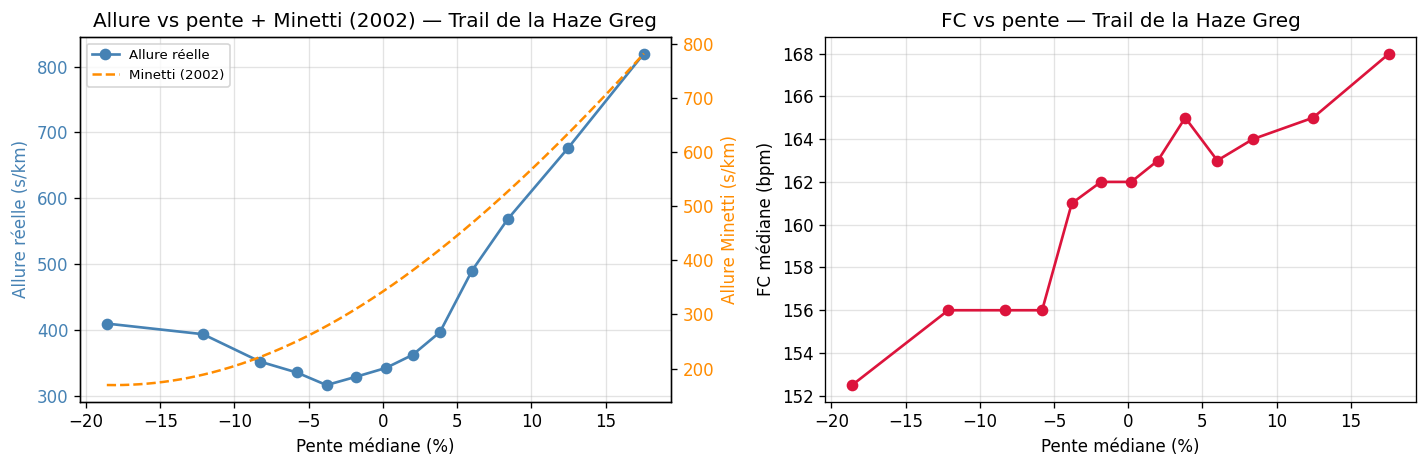

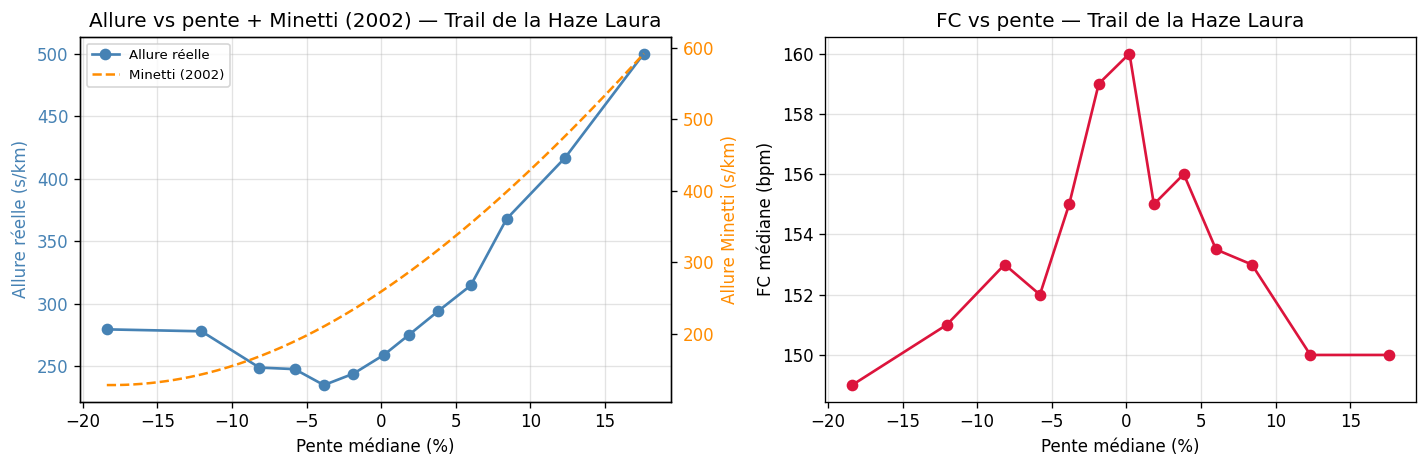

In [9]:
from trail_analysis import plot_pace_vs_slope

# Bins de pente — adapter si le profil est très alpin (étendre à ±40)
BINS_SLOPE = [-30, -15, -10, -7, -5, -3, -1, 1, 3, 5, 7, 10, 15, 30]

for race in races:
    plot_pace_vs_slope(
        race['df'],
        label=race['meta']['name'],
        bins_slope=BINS_SLOPE,
    )

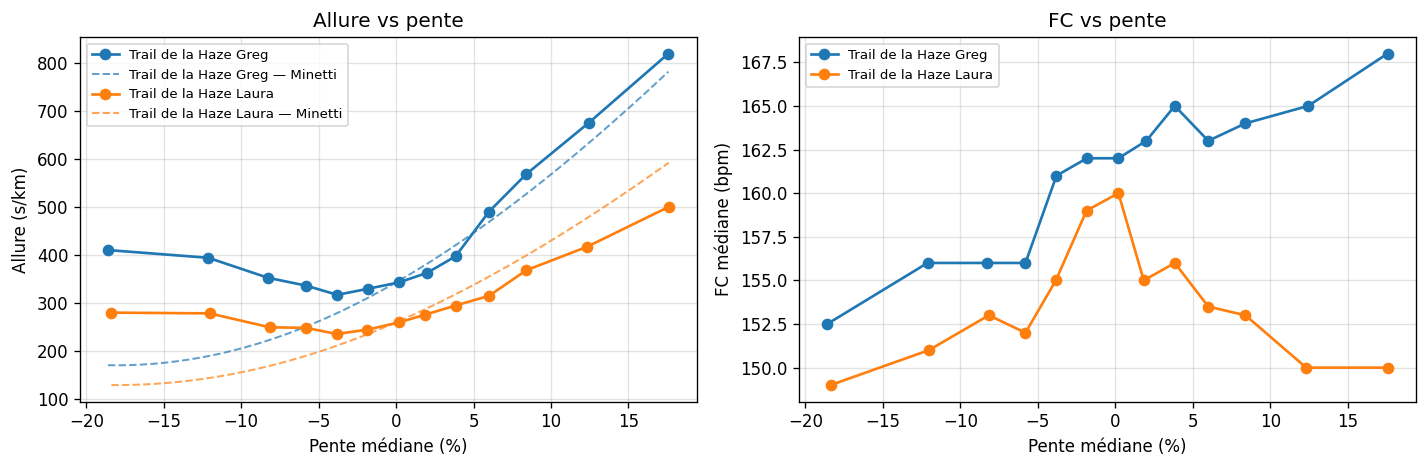

In [10]:
from trail_analysis import plot_pace_vs_slope_overlay

plot_pace_vs_slope_overlay(
    races,
    bins_slope=BINS_SLOPE,
    show_minetti=True,
)

## 7b. Écart relatif à Minetti par classe de pente

> Pour chaque course, on calcule l'écart relatif entre l'allure réelle et
> l'allure prédite par Minetti (2002), recalée sur l'allure à plat de chaque
> course : `(allure_réelle - allure_Minetti) / allure_Minetti`.

> **Comment lire ce graphe :**
> - **0 %** : l'allure réelle correspond exactement à la prédiction Minetti.
> - **Valeur positive** : tu cours plus lentement que Minetti — coût mécanique
>   supérieur au modèle (terrain technique, fatigue, freinage en descente).
> - **Valeur négative** : tu cours plus vite que Minetti — efficacité supérieure
>   au modèle sur ce type de terrain.

> Ce graphe isole la **signature biomécanique par type de terrain**,
> indépendamment du niveau d'effort absolu de chaque course. Deux courses aux
> allures très différentes sont ici directement comparables.

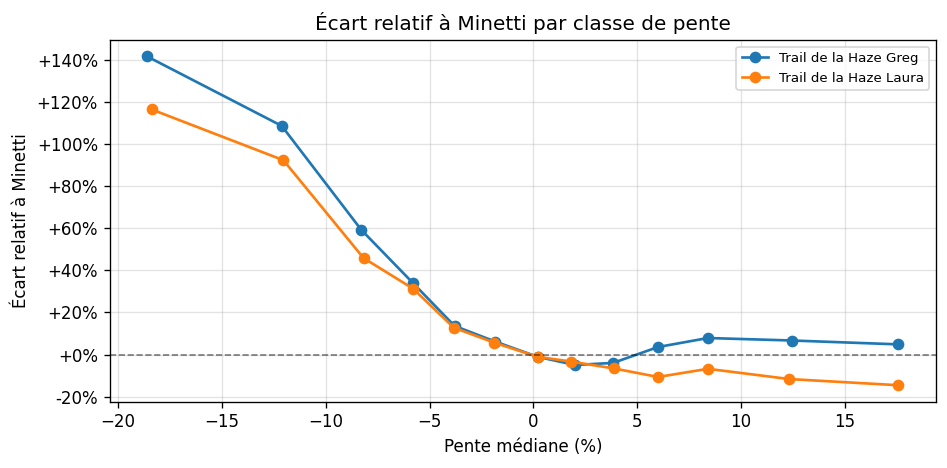

In [11]:
from trail_analysis import plot_pace_vs_slope_deviation

plot_pace_vs_slope_deviation(
    races,
    bins_slope=BINS_SLOPE,
)

---
## 6. Profils circadiens comparés

> Pour les courses nocturnes : comparer le creux circadien entre plusieurs éditions d'une même course (ex. SaintéLyon 2024 vs 2025) ou entre courses nocturnes différentes.

> La tranche horaire est la même pour toutes les courses — les profils sont directement superposables si les heures de départ sont proches.

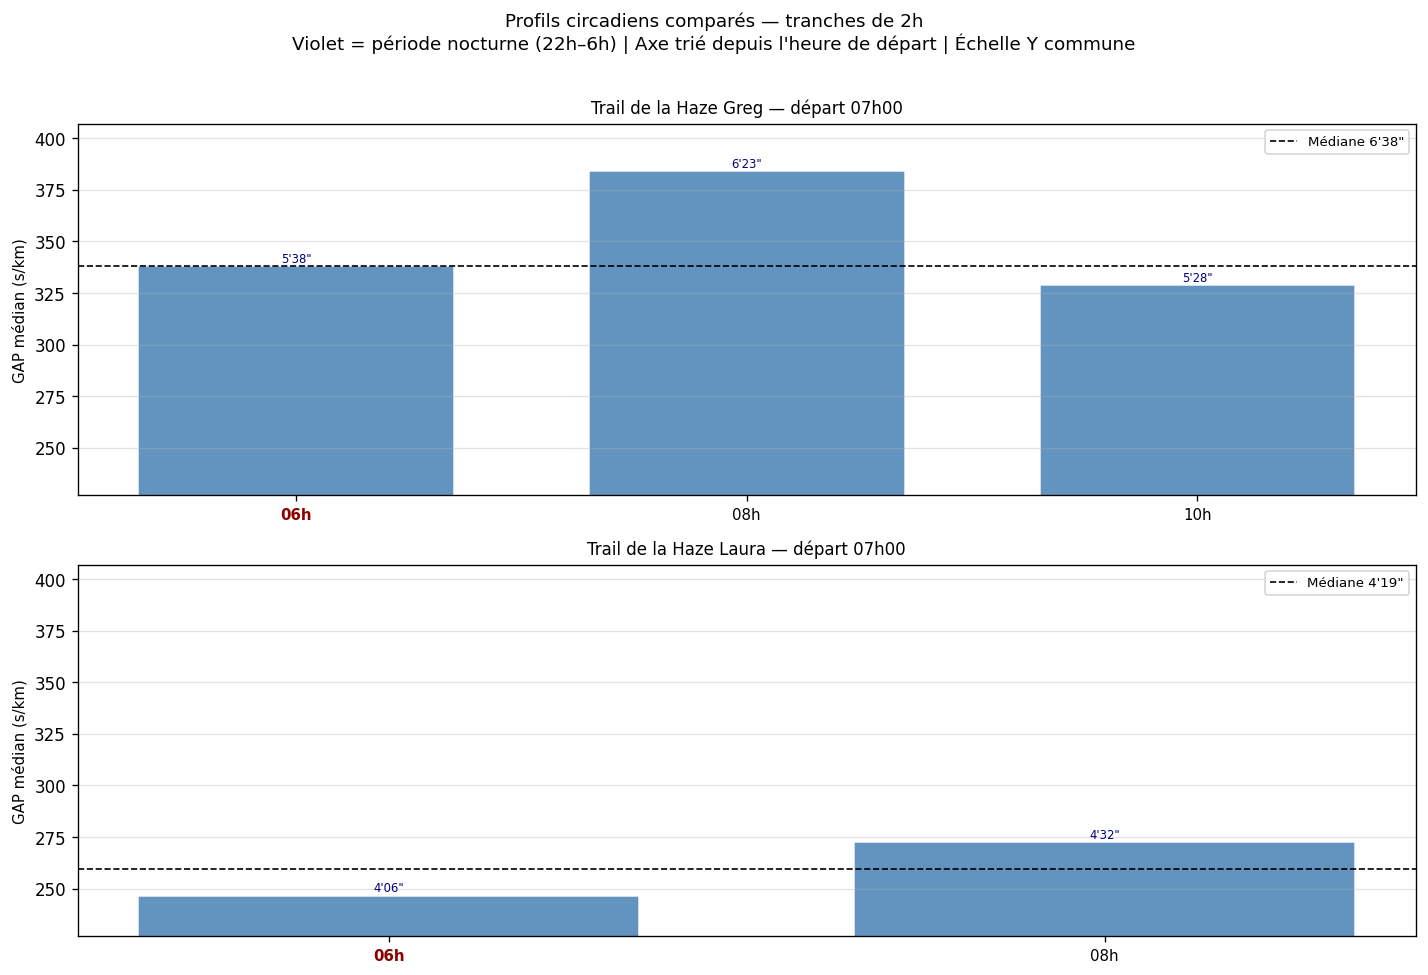

In [12]:
BIN_HOURS = 2

# ── Calcul des bins pour chaque course ─────────────────────────────────────
# Tri chronologique depuis l'heure de départ (pas numérique).
# Ex : course démarrant à 23h → ordre : 22h, 00h, 02h, 04h, 06h…
# On représente l'axe en "heures depuis minuit" mais on trie depuis start_hour.

def circadian_bins_ordered(df, bin_hours, start_hour_override=None):
    """Return (bins_ordered, gap_by_bin, labels, is_nocturnal) sorted from race start."""
    df2 = df.copy()
    df2['hour'] = df2['timestamp'].dt.hour
    df2['hour_bin'] = (df2['hour'] // bin_hours) * bin_hours

    all_bins = sorted(df2['hour_bin'].unique())
    if not all_bins:
        return [], [], [], []

    # Heure de départ arrondie au bin inférieur
    start_h = (start_hour_override
               if start_hour_override is not None
               else int(df2['timestamp'].iloc[0].hour))
    start_bin = (start_h // bin_hours) * bin_hours

    # Rotation : mettre start_bin en premier
    if start_bin in all_bins:
        idx = all_bins.index(start_bin)
        bins_ordered = all_bins[idx:] + all_bins[:idx]
    else:
        bins_ordered = all_bins

    gap_by_bin, labels, is_noc = [], [], []
    for h in bins_ordered:
        mask = (
            (df2['hour_bin'] == h) &
            df2['gap_s_per_km'].notna() &
            (df2['gap_s_per_km'] > 0) &
            (df2['gap_s_per_km'] < 1200)
        )
        val = df2.loc[mask, 'gap_s_per_km'].median()
        gap_by_bin.append(val)
        labels.append(f"{h:02d}h")
        is_noc.append(h >= 22 or h < 6)

    return bins_ordered, gap_by_bin, labels, is_noc


# ── Collecter les bins de toutes les courses pour aligner les axes ──────────
all_bin_data = []
for race in races:
    df = race['df']
    if 'timestamp' not in df.columns or 'gap_s_per_km' not in df.columns:
        all_bin_data.append(None)
        continue
    bins, gaps, labels, noc = circadian_bins_ordered(df, BIN_HOURS)
    all_bin_data.append({
        'bins': bins, 'gaps': gaps, 'labels': labels, 'noc': noc
    })

# Plage Y commune (exclure NaN)
all_gaps = [g for d in all_bin_data if d
            for g in d['gaps'] if not np.isnan(g)]
y_min = max(0, np.nanmin(all_gaps) * 0.92) if all_gaps else 0
y_max = np.nanmax(all_gaps) * 1.06 if all_gaps else 600

# ── Figure verticale : une ligne par course ─────────────────────────────────
n_races = len(races)
fig, axes = plt.subplots(n_races, 1,
                         figsize=(12, 4 * n_races),
                         squeeze=False)

for row, (race, data) in enumerate(zip(races, all_bin_data)):
    ax = axes[row, 0]

    if data is None:
        ax.set_title(f"{race['meta']['name']}\n(données insuffisantes)")
        continue

    bins, gaps, labels, noc = (
        data['bins'], data['gaps'], data['labels'], data['noc']
    )
    colors = ['mediumpurple' if n else 'steelblue' for n in noc]
    x_pos = np.arange(len(bins))

    bars = ax.bar(x_pos, gaps, color=colors, alpha=0.85, edgecolor='white',
                  width=0.7)

    # Médiane globale de la course (ligne de référence)
    median_gap = np.nanmedian(gaps)
    ax.axhline(median_gap, color='black', linestyle='--', linewidth=1.0,
               label=f'Médiane {median_gap/60:.0f}\'{int(median_gap)%60:02d}\"')

    # Annoter chaque barre
    for bar, val in zip(bars, gaps):
        if not np.isnan(val):
            m, s = int(val) // 60, int(val) % 60
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + (y_max - y_min) * 0.01,
                    f"{m}'{s:02d}\"", ha='center', fontsize=7, color='navy')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('GAP médian (s/km)', fontsize=9)
    ax.set_title(
        f"{race['meta']['name']} — départ {race['df']['timestamp'].iloc[0].strftime('%Hh%M')}",
        fontsize=10
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, axis='y', alpha=0.35)

    # Heure de départ marquée
    start_h = race['df']['timestamp'].iloc[0].hour
    start_bin = (start_h // BIN_HOURS) * BIN_HOURS
    if start_bin in bins:
        idx_start = bins.index(start_bin)
        ax.get_xticklabels()[idx_start].set_fontweight('bold')
        ax.get_xticklabels()[idx_start].set_color('darkred')

fig.suptitle(
    f'Profils circadiens comparés — tranches de {BIN_HOURS}h\n'
    'Violet = période nocturne (22h–6h) | '
    'Axe trié depuis l\'heure de départ | Échelle Y commune',
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.show()


In [13]:
from trail_analysis import load_and_process_race
from trail_report import generate_report

# Charge tes courses avec la même API que race_compare.ipynb
# RACES_CATALOG = [
#     {
#         'label':      'SaintéLyon 2025',
#         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/SainteLyon_2025-11-29 23:31:00.fit',
#         'ravito_km':  [19.2, 34.0, 45.0, 58.8, 65.4],
#         'ravito_nom': ['St Christo', 'Ste Catherine', 'St Genou', 'Soucieu', 'Chaponost'],
#     },

#     {
#          'label':      'Ecotrail80 2026',
#          'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/EcoTrail de Paris_2026-03-21 10:55:00.fit',
#          'ravito_km':  [25.4, 37.7, 47.7, 53.8, 78.3],
#          'ravito_nom': ['Buc', 'Chaville', 'Saint Philippe', 'Marcel Bec', 'Saint Cloud'],
#     },
#     {
#          'label':      'Impérial trail 2025',
#          'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Imperial trail de Fontainebleau_2025-09-13 06:01:00.fit',
#          'ravito_km':  [11, 23.5, 33.5, 46.7, 61],
#          'ravito_nom': ['ravito1', 'ravito2', 'ravito3', 'ravito4', 'ravito5'],
#     },

#     {
#          'label':      'Trail de la Haze 2026',
#          'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Trail-de-la-haze_2026_05_03 09:00:00.fit',
#          'ravito_km':  [10.4],
#          'ravito_nom': ['ravito1'],
#     },

# ]

RACES_CATALOG = [
    {
        'label':      'SaintéLyon 2025',
        'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/SainteLyon_2025-11-29 23:31:00.fit',
        'ravito_km':  [19.2, 34.0, 45.0, 58.8, 65.4],
        'ravito_nom': ['St Christo', 'Ste Catherine', 'St Genou', 'Soucieu', 'Chaponost'],
    },

    {
         'label':      'Ecotrail80 2026',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/EcoTrail de Paris_2026-03-21 10:55:00.fit',
         'ravito_km':  [25.4, 37.7, 47.7, 53.8, 78.3],
         'ravito_nom': ['Buc', 'Chaville', 'Saint Philippe', 'Marcel Bec', 'Saint Cloud'],
    },
    {
         'label':      'Impérial trail 2025',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Imperial trail de Fontainebleau_2025-09-13 06:01:00.fit',
         'ravito_km':  [11, 23.5, 33.5, 46.7, 61],
         'ravito_nom': ['ravito1', 'ravito2', 'ravito3', 'ravito4', 'ravito5'],
    },

    {
         'label':      'Trail de la Haze 2026',
         'fit_path':   '/home/gsainton/01_CODES/Twinity/data/export_nolio_Greg_Sainton/Trail-de-la-haze_2026_05_03 09:00:00.fit',
         'ravito_km':  [10.4],
         'ravito_nom': ['ravito1'],
    },

]


# Process race with kpi + profile analyses
race1 = load_and_process_race(fit_path=RACES_CATALOG[0]['fit_path'], fc_max=185, fc_min=47,
                               poids_kg=79.0, ravito_km=RACES_CATALOG[0]['ravito_km'], 
                               ravito_nom=RACES_CATALOG[0]['ravito_nom'])
race1["meta"]["name"] = "SaintéLyon 2025"

race2 = load_and_process_race(fit_path=RACES_CATALOG[1]['fit_path'], fc_max=185, fc_min=47,
                               poids_kg=79.0, ravito_km=RACES_CATALOG[1]['ravito_km'], 
                               ravito_nom=RACES_CATALOG[1]['ravito_nom'])
race2["meta"]["name"] = "Ecotrail80 2026"

race3 = load_and_process_race(fit_path=RACES_CATALOG[2]['fit_path'], fc_max=185, fc_min=47,
                               poids_kg=79.0, ravito_km=RACES_CATALOG[2]['ravito_km'], ravito_nom=RACES_CATALOG[2]['ravito_nom'])
race3["meta"]["name"] = "Impérial trail 2025"   

race4 = load_and_process_race(fit_path=RACES_CATALOG[3]['fit_path'], fc_max=185, fc_min=47,
                               poids_kg=79.0, ravito_km=RACES_CATALOG[3]['ravito_km'], ravito_nom=RACES_CATALOG[3]['ravito_nom'])
race4["meta"]["name"] = "Trail de la Haze 2026"

# Génère le PDF
import pandas as pd
output_dir  = '/home/gsainton/99_OUTPUT_CODE/trail_lab'
date_report = pd.Timestamp.now().strftime('%Y-%m-%d')
output_path = f"{output_dir}/{date_report}_{ATHELETE_NAME}_rapport_coach.pdf"

generate_report(
    races=[race1, race2, race3, race4],
    output_path=output_path,
    athlete_name=ATHELETE_NAME
)

✓ Rapport généré : /home/gsainton/99_OUTPUT_CODE/trail_lab/2026-05-12_Laura_rapport_coach.pdf


'/home/gsainton/99_OUTPUT_CODE/trail_lab/2026-05-12_Laura_rapport_coach.pdf'